In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score, confusion_matrix
import seaborn as sns

In [2]:
# Load dataset (train only)
train_df = pd.read_csv("train_loan_dataset.csv")

# Data Preprocessing
train_df.drop('Loan_ID', axis=1, inplace=True)

# Handle missing values
cat_cols = train_df.select_dtypes(include='object').columns.drop('Loan_Status')
num_cols = train_df.select_dtypes(exclude='object').columns

# For categorical columns
for col in cat_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# For numerical columns
for col in num_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())

In [3]:
# Encode categorical variables
le = LabelEncoder()
for col in cat_cols:
    train_df[col] = le.fit_transform(train_df[col])
train_df['Loan_Status'] = le.fit_transform(train_df['Loan_Status'])  # Y=1, N=0

# Split dataset into training, validation, and test sets (80% for train, 20% for validation + test)
X = train_df.drop('Loan_Status', axis=1)
y = train_df['Loan_Status']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Split remaining 20% into validation and test sets (10% for validation, 10% for test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [4]:
# Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
train_preds = nb_model.predict(X_train)
val_preds = nb_model.predict(X_val)
test_preds = nb_model.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, train_preds)
val_accuracy = accuracy_score(y_val, val_preds)
test_accuracy = accuracy_score(y_test, test_preds)

print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.7922606924643585
Validation Accuracy: 0.819672131147541
Test Accuracy: 0.8709677419354839


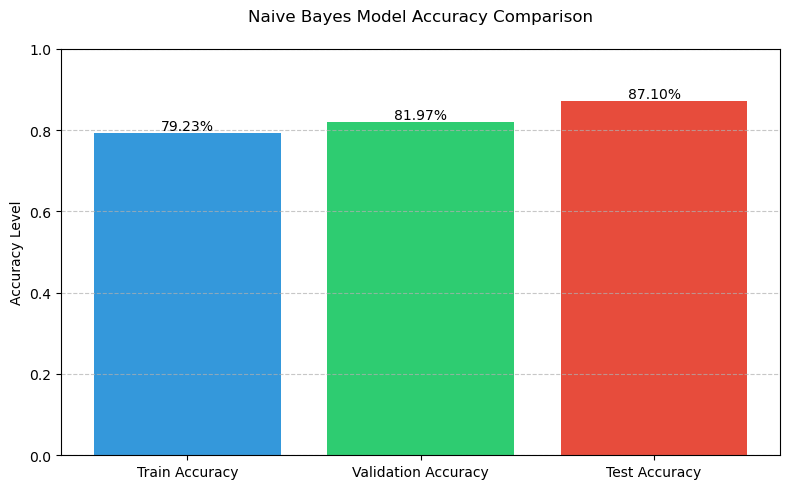

In [5]:
# Plot bar chart for accuracies
accuracies = [train_accuracy, val_accuracy, test_accuracy]
labels = ['Train Accuracy', 'Validation Accuracy', 'Test Accuracy']
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Create bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, color=colors)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}', ha='center', va='bottom')

# Customize plot
plt.title('Naive Bayes Model Accuracy Comparison', pad=20)
plt.ylabel('Accuracy Level')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

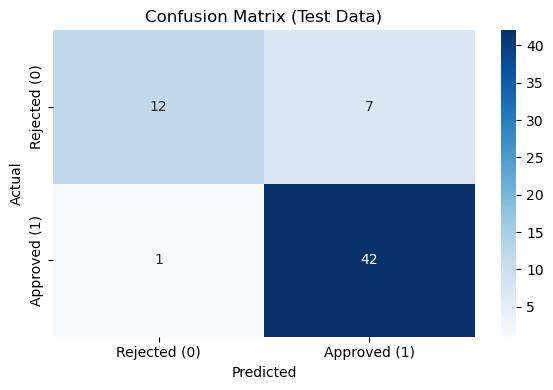

Classification Report:
              precision    recall  f1-score   support

Rejected (N)       0.92      0.63      0.75        19
Approved (Y)       0.86      0.98      0.91        43

    accuracy                           0.87        62
   macro avg       0.89      0.80      0.83        62
weighted avg       0.88      0.87      0.86        62



In [6]:
# Generate confusion matrix for test set
cm = confusion_matrix(y_test, test_preds)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.title('Confusion Matrix (Test Data)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Get classification report for test set
class_report = classification_report(y_test, test_preds, target_names=['Rejected (N)', 'Approved (Y)'])
print("Classification Report:")
print(class_report)

Evaluation Metrics:
                                 Metric    Value
                          ROC AUC Score 0.745410
True Positive Rate (Recall/Sensitivity) 0.976744
                    False Positive Rate 0.368421
       True Negative Rate (Specificity) 0.631579
                    False Negative Rate 0.023256


<Figure size 800x600 with 0 Axes>

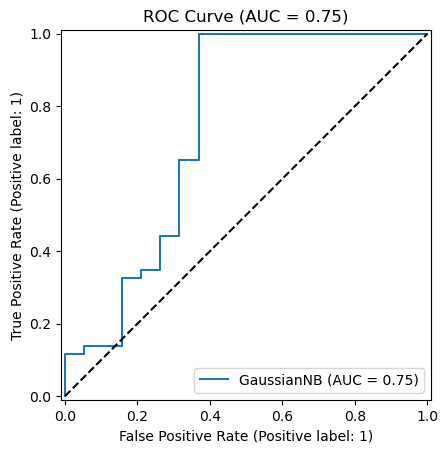

In [12]:
# Get predicted probabilities for the test set
test_probs = nb_model.predict_proba(X_test)[:, 1]

# Calculate ROC AUC Score
roc_auc = roc_auc_score(y_test, test_probs)

# Calculate confusion matrix values
cm = confusion_matrix(y_test, test_preds)
tn, fp, fn, tp = cm.ravel()

# Calculate rates
true_positive_rate = tp / (tp + fn)
false_positive_rate = fp / (fp + tn)
true_negative_rate = tn / (tn + fp)
false_negative_rate = fn / (tp + fn)

# Create DataFrame to display evaluation metrics
metrics_df = pd.DataFrame({
    'Metric': ['ROC AUC Score', 'True Positive Rate (Recall/Sensitivity)', 
               'False Positive Rate', 'True Negative Rate (Specificity)', 
               'False Negative Rate'],
    'Value': [roc_auc, true_positive_rate, false_positive_rate, 
              true_negative_rate, false_negative_rate],
})

# Print the metrics
print("Evaluation Metrics:")
print(metrics_df.to_string(index=False))

# Plot ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(nb_model, X_test, y_test)
plt.title('ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.show()


In [18]:
#Take 5 samples from X_test
sample_indices = X_test.sample(5, random_state=42).index
X_sample = X_test.loc[sample_indices]
y_sample = y_test.loc[sample_indices]

#Make predictions
sample_preds = nb_model.predict(X_sample)

#Map 0 ➔ 'N', 1 ➔ 'Y'
map_labels = {0: 'N', 1: 'Y'}
actual_labels = pd.Series(y_sample).map(map_labels)
predicted_labels = pd.Series(sample_preds).map(map_labels)

#Create a results DataFrame
sample_results = pd.DataFrame({
    'Actual_Status': actual_labels.values,
    'Predicted_Status': predicted_labels.values
})

#Display
print("\nSample Predictions (Y/N):")
print(sample_results.to_string(index=False))


Sample Predictions (Y/N):
Actual_Status Predicted_Status
            Y                Y
            Y                Y
            Y                Y
            Y                Y
            N                N
